In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [ ]:
def lineal (x, a ,b):
    '''
    Esta función será usada para hacer un ajuste  a la ecución del efeco
    fotoeléctrico
    a, b : parámetros de la función lineal
    x : valor de la variable independiente

    return
    valores de la funcion dados los párametros y los valores
    de la variable independiente
    '''
    return a * x + b

c = 299792458

# Primera parte del experimento

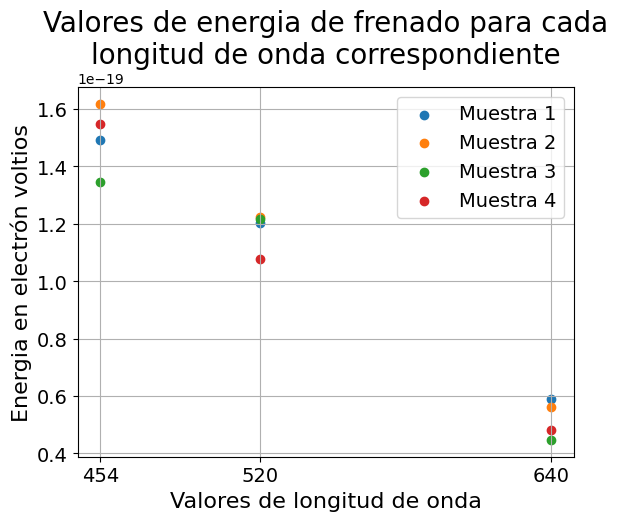

In [ ]:
# Array de las longitudes de onda y los voltajes de frenado para varios intentos

data = np.array(
        [['lambda',640e-9, 5201e-9, 4541e-9],
        [1, 368, 752, 931 ],
        [2, 351, 765, 1010],
        [3, 279, 759, 840],
        [4, 301, 672, 966]])

# Gráfica para cada muestra de la magnitud del pico en electron voltios vs la longitud de onda
plt.title('Valores de energia de frenado para cada\nlongitud de onda correspondiente',
          fontsize = 20)
l = data[0, 1:].astype(float)

for i in range(1,5):
   
    y = data[i, 1:].astype(float)
    plt.scatter(l,y*1.602e-22, label = f'Muestra {i}')

plt.legend(fontsize = 14)
plt.xticks(l, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlabel('Valores de longitud de onda', fontsize = 16)
plt.ylabel('Energia en electrón voltios', fontsize = 16)
plt.grid()

## Ajuste lineal de la ley de planck

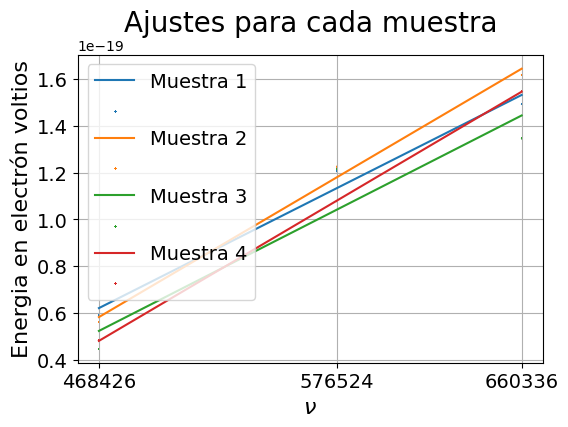

In [ ]:
# Realizamos ajuste lineal de los datos para cada caso
a = np.zeros(4)
b = np.zeros(4)
cova = np.zeros(4)
covb = np.zeros(4)
nu = c/l
plt.figure(figsize = (6,4))
plt.title('Ajustes para cada muestra', fontsize = 20)
for i in range(4):
    y = data[i + 1 , 1:].astype(float)
    E = y*1.602e-22 #Energía en electron voltios
    
    par, cov = curve_fit(lineal,nu ,E )
    a[i] = par[0]
    b[i] = par[1]
    cova = cov[0,0]
    covb = cov[1,1]

    plt.plot(nu, lineal(nu, a[i], b[i]),  label = f'Muestra {i +1}')
    plt.scatter(nu,y*1.602e-22, E, label = ' ')
    
plt.legend(fontsize = 14)
plt.xticks(nu, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlabel('$\\nu$', fontsize = 16)
plt.ylabel('Energia en electrón voltios', fontsize = 16)
plt.grid()

In [ ]:
a

array([4.74658045e-25, 5.53109088e-25, 4.79792512e-25, 5.54868652e-25])

# Parte 2

## Voltajes del pico de emisión correspondientes a cada led
Dados tres led rojo, azul y verde, conéctelos a una fuente DC con voltaje de 1.8 V para el rojo, 2.3 V para el verde y 2.8 V para el azul. Mida con el
espectrómetro su longitud de onda pico.

In [ ]:
Picos = np.array([ 688.32e-9, 526.64e-9, 461.23e-9])
Voltaje = np.array([2, 2.4, 2.8 ])

Luego conecte cada led directamente a la fuente DC, con el voltaje de esta en 1.4 V. Aumente lentamente el voltaje hasta que el led empiece a emitir. Anote a que voltaje ocurre esto para cada led.
Grafique longitud de onda pico vs voltaje y ajuste a una recta.

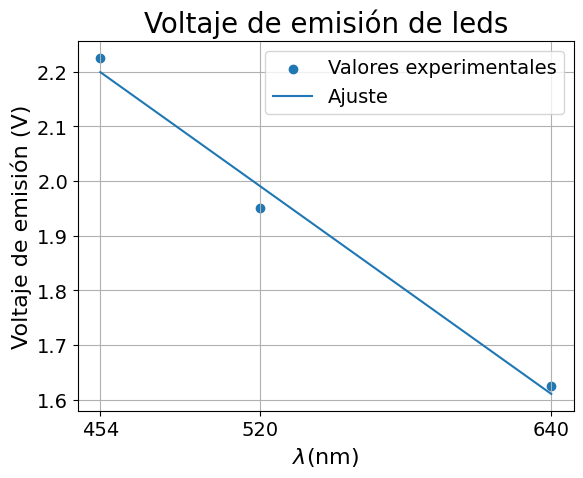

In [ ]:
V_em = np.array([ 1.625, 1.950, 2.225]) #Valores de los voltjes de emision

#Ajuste lineal a la longitud de onda correspondiente

parametros, cov = curve_fit(lineal, l, V_em) 
a = parametros[0]
b = parametros[1]

#Gráficas
plt.title('Voltaje de emisión de leds', fontsize = 20)
plt.scatter(l, V_em, label = 'Valores experimentales')
plt.plot(l, lineal(l, a, b), label = 'Ajuste')
plt.legend(fontsize = 14)
plt.xticks(l, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlabel(f'$\\lambda$(nm)', fontsize = 16)
plt.ylabel('Voltaje de emisión (V)', fontsize = 16)

plt.grid()

In [ ]:
print(a)

-0.0031629554686839127


¿Que es la pendiente y el intercepto en este caso?
 Rta: En este caso estamos encontrando la energía en la que hay emisión, por tanto se cumple que h $\nu$ = $ V_{em} $

 ¿Se puede obtener el valor de la
constante de Plank? 

¿Cuál método es más preciso?